# Peak Angle Analysis

Compares maximum (peak) joint angles per video for:
- **MoLAB** IMU reference
- **SAT korrigerat** (keypoints_corrected, hip corrected)
- **SAT ej korrigerat** (keypoints_combined, raw)

Joints: knee (avg L+R), hip (avg L+R), ankle (avg L+R), pelvis.  
Both directions: sit-to-stand and stand-to-sit.

In [23]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

VIDEO_FPS    = 50
VIDEO_ASPECT = 1920 / 1080

MAPPING = [
    ('0028','Fp1_SB'),('0030','Fp1_SB'),
    ('0045','Fp2_CF'),('0047','Fp2_CF'),
    ('0059','Fp3_JN'),('0061','Fp3_JN'),
    ('0074','Fp4_AL'),('0076','Fp4_AL'),
    ('0091','Fp5_WL'),('0093','Fp5_WL'),
]

BEEP_TIMES  = {'0028':9.14,'0030':5.38,'0045':5.88,'0047':6.12,
               '0059':5.70,'0061':6.10,'0074':5.42,'0076':5.54,
               '0091':5.52,'0093':5.00}
CORRECTIONS = {'0028': 0.52}

DIRS = {
    'sit_to_stand': {
        'raw':   '../data/processed/keypoints_combined',
        'corr':  '../data/processed/keypoints_corrected',
        'molab': '../data/processed/molab_cropped',
    },
    'stand_to_sit': {
        'raw':   '../data/processed/keypoints_combined_down',
        'corr':  '../data/processed/keypoints_corrected_down',
        'molab': '../data/processed/molab_cropped_down',
    },
}

ML_JOINTS = {
    'hip':  ['JointAngle/L_hip_X',   'JointAngle/R_hip_X'],
    'knee': ['JointAngle/L_knee_X',  'JointAngle/R_knee_X'],
    'heel': ['JointAngle/L_ankle_X', 'JointAngle/R_ankle_X'],
    'bal':  ['JointAngle/pelvis_X'],
}
ALL_ML_COLS = [c for cols in ML_JOINTS.values() for c in cols]

In [24]:
def joint_angle_2d(ax, ay, bx, by, cx, cy):
    v1x, v1y = ax - bx, ay - by
    v2x, v2y = cx - bx, cy - by
    dot  = v1x*v2x + v1y*v2y
    norm = np.sqrt(v1x**2 + v1y**2) * np.sqrt(v2x**2 + v2y**2) + 1e-8
    return 180 - np.degrees(np.arccos(np.clip(dot / norm, -1, 1)))

def trunk_angle_2d(kp):
    mid_hip_x = (kp['left_hip_x'].values + kp['right_hip_x'].values) / 2
    mid_hip_y = (kp['left_hip_y'].values + kp['right_hip_y'].values) / 2
    mid_sh_x  = (kp['left_shoulder_x'].values + kp['right_shoulder_x'].values) / 2
    mid_sh_y  = (kp['left_shoulder_y'].values + kp['right_shoulder_y'].values) / 2
    dx = mid_sh_x - mid_hip_x
    dy = mid_sh_y - mid_hip_y
    return -np.degrees(np.arctan2(dx, -dy))

def compute_kp_angles(kp):
    kp = kp.copy()
    for c in kp.columns:
        if c.endswith('_x'):
            kp[c] *= VIDEO_ASPECT
    a = {}
    for side, s in [('L', 'left'), ('R', 'right')]:
        a[f'{side}_hip'] = joint_angle_2d(
            kp[f'{s}_shoulder_x'].values, kp[f'{s}_shoulder_y'].values,
            kp[f'{s}_hip_x'].values,      kp[f'{s}_hip_y'].values,
            kp[f'{s}_knee_x'].values,     kp[f'{s}_knee_y'].values)
        a[f'{side}_knee'] = joint_angle_2d(
            kp[f'{s}_hip_x'].values,   kp[f'{s}_hip_y'].values,
            kp[f'{s}_knee_x'].values,  kp[f'{s}_knee_y'].values,
            kp[f'{s}_ankle_x'].values, kp[f'{s}_ankle_y'].values)
        a[f'{side}_heel'] = joint_angle_2d(
            kp[f'{s}_knee_x'].values,  kp[f'{s}_knee_y'].values,
            kp[f'{s}_ankle_x'].values, kp[f'{s}_ankle_y'].values,
            kp[f'{s}_heel_x'].values,  kp[f'{s}_heel_y'].values)
    a['bal'] = trunk_angle_2d(kp)
    return a

## Data Loading

Load keypoints (raw + corrected) and MoLAB data, compute peak angles for all videos.

In [25]:
ml_offsets = {}
for vid, _ in MAPPING:
    full = pd.read_csv(f'../data/processed/molab/{vid}_molab.csv')
    pre  = full[full['molab_frame'] < 41]
    ml_offsets[vid] = {col: pre[col].mean() for col in ALL_ML_COLS if col in full.columns}

rows = []
for direction, cfg in DIRS.items():
    for vid, fp in MAPPING:
        molab_f = glob.glob(f"{cfg['molab']}/{vid}_molab.csv")
        raw_f   = glob.glob(f"{cfg['raw']}/DJI_*_{vid}_D.csv")
        corr_f  = glob.glob(f"{cfg['corr']}/DJI_*_{vid}_D.csv")
        if not (molab_f and raw_f and corr_f):
            print(f'  SKIP {vid} {direction}')
            continue

        molab = pd.read_csv(molab_f[0])
        raw   = pd.read_csv(raw_f[0])
        corr  = pd.read_csv(corr_f[0])

        mask = molab['molab_frame'].values >= 41

        ml_peaks = {}
        for group, cols in ML_JOINTS.items():
            peak_vals = []
            for col in cols:
                if col not in molab.columns:
                    continue
                vals = molab[col].values.copy()
                vals[mask] += ml_offsets[vid].get(col, 0)
                peak_vals.append(np.max(np.abs(vals)))
            ml_peaks[group] = np.mean(peak_vals) if peak_vals else np.nan

        raw_a  = compute_kp_angles(raw)
        corr_a = compute_kp_angles(corr)

        def sat_peak_lr(a, joint):
            return np.mean([np.max(np.abs(a[f'L_{joint}'])), np.max(np.abs(a[f'R_{joint}']))])

        rows.append({
            'direction':   direction,
            'video':       vid,
            'participant': fp,
            'molab_hip':   round(ml_peaks.get('hip',  np.nan), 1),
            'molab_knee':  round(ml_peaks.get('knee', np.nan), 1),
            'molab_heel':  round(ml_peaks.get('heel', np.nan), 1),
            'molab_bal':   round(ml_peaks.get('bal',  np.nan), 1),
            'raw_hip':     round(sat_peak_lr(raw_a, 'hip'),  1),
            'raw_knee':    round(sat_peak_lr(raw_a, 'knee'), 1),
            'raw_heel':    round(sat_peak_lr(raw_a, 'heel'), 1),
            'raw_bal':     round(np.max(np.abs(raw_a['bal'])), 1),
            'corr_hip':    round(sat_peak_lr(corr_a, 'hip'),  1),
            'corr_knee':   round(sat_peak_lr(corr_a, 'knee'), 1),
            'corr_heel':   round(sat_peak_lr(corr_a, 'heel'), 1),
            'corr_bal':    round(np.max(np.abs(corr_a['bal'])), 1),
        })

peak_df = pd.DataFrame(rows)
print(f'Computed peaks for {len(peak_df)} video x direction combinations')

Computed peaks for 20 video x direction combinations


## Results Tables

In [26]:
JOINTS  = ['hip',       'knee',        'heel',          'bal']
JLABELS = ['Hip (deg)', 'Knee (deg)', 'Ankle (deg)', 'Pelvis (deg)']

def make_table(direction):
    sub = peak_df[peak_df['direction'] == direction].copy().set_index('video')
    cols   = ['participant']
    tuples = [('', 'Deltagare')]
    for jk, jl in zip(JOINTS, JLABELS):
        for src, sl in [('molab','MoLAB'), ('raw','SAT ra'), ('corr','SAT korr')]:
            cols.append(f'{src}_{jk}')
            tuples.append((jl, sl))
    sub = sub[cols]
    sub.columns = pd.MultiIndex.from_tuples(tuples)
    return sub

print('=== Sit-to-stand: Max peak vinklar (grader) ===')
display(make_table('sit_to_stand'))

=== Sit-to-stand: Max peak vinklar (grader) ===


Hip (deg)                 Knee (deg)                  \
      Deltagare     MoLAB SAT ra SAT korr      MoLAB SAT ra SAT korr   
video                                                                  
0028     Fp1_SB      96.3   87.9     93.6       94.7   78.8     82.7   
0030     Fp1_SB     115.6   85.5    101.5      100.3   80.7     91.7   
0045     Fp2_CF     106.2   90.5     90.5       83.0   75.4     75.3   
0047     Fp2_CF     117.9   89.0    105.3       90.9   73.8     84.9   
0059     Fp3_JN      90.4   97.2     98.9       91.2   83.1     84.2   
0061     Fp3_JN      95.5   73.7     92.9       95.8   71.6     86.5   
0074     Fp4_AL     103.4   88.9    101.8      102.4   90.6    101.0   
0076     Fp4_AL     116.3   86.6    102.2      102.3   79.8     90.1   
0091     Fp5_WL     105.3   81.1     90.4       82.6   74.8     80.3   
0093     Fp5_WL     111.1   72.4     87.2       92.1   73.7     83.0   

      Ankle (deg)                 Pelvis (deg)                  
            MoLAB SAT ra SAT korr        MoLAB SAT ra SAT korr  
video                                                           
0028         77.7   35.0     34.9         32.9   33.7     35.7  
0030         81.7   36.5     36.3         53.1   40.2     44.8  
0045         78.3   36.2     35.1         52.7   36.5     36.5  
0047         84.2   33.2     32.7         64.1   38.0     42.8  
0059         81.4   48.2     47.1         38.2   45.7     46.2  
0061         83.8   39.7     40.1         44.2   31.1     37.2  
0074         91.4   47.9     45.7         39.9   20.1     26.5  
0076         91.4   33.4     32.7         56.6   35.0     39.9  
0091         70.4   36.4     36.0         43.8   24.9     28.0  
0093         85.6   31.5     31.7         53.2   25.6     31.1

In [27]:
print('=== Stand-to-sit: Max peak vinklar (grader) ===')
display(make_table('stand_to_sit'))

=== Stand-to-sit: Max peak vinklar (grader) ===


Hip (deg)                 Knee (deg)                  \
      Deltagare     MoLAB SAT ra SAT korr      MoLAB SAT ra SAT korr   
video                                                                  
0028     Fp1_SB      92.3   81.3     86.5      100.2   79.9     83.5   
0030     Fp1_SB     100.5   81.4     98.9      101.9   84.2     97.4   
0045     Fp2_CF     111.9   93.2     99.0       85.3   76.9     81.9   
0047     Fp2_CF     116.8   90.0    107.1       88.7   73.6     87.2   
0059     Fp3_JN      93.4   88.4     90.6       88.7   74.7     76.5   
0061     Fp3_JN      84.2   72.8     84.3       92.4   72.8     80.3   
0074     Fp4_AL     117.8   89.0    105.2      102.3   84.6     97.5   
0076     Fp4_AL     107.2   78.0     97.9      101.8   83.3     96.5   
0091     Fp5_WL     105.4   82.2     94.3       85.9   73.1     81.2   
0093     Fp5_WL     100.6   78.5     94.3       87.4   70.4     81.1   

      Ankle (deg)                 Pelvis (deg)                  
            MoLAB SAT ra SAT korr        MoLAB SAT ra SAT korr  
video                                                           
0028         82.7   33.2     32.5         34.3   32.6     34.1  
0030         86.7   34.3     33.7         46.2   36.5     41.4  
0045         83.1   38.2     36.8         60.4   38.8     40.2  
0047         85.6   33.9     33.6         68.7   40.2     44.4  
0059         76.7   34.3     34.2         41.6   40.7     41.3  
0061         85.3   38.6     38.4         38.9   28.4     31.9  
0074         95.0   33.1     33.2         49.8   25.2     31.2  
0076         94.8   32.9     32.5         51.9   24.3     31.1  
0091         84.0   32.1     32.5         46.6   26.2     30.3  
0093         80.7   34.2     33.8         51.7   29.6     34.9

## Summary

In [28]:
summary_rows = []
for direction in ['sit_to_stand', 'stand_to_sit']:
    sub   = peak_df[peak_df['direction'] == direction]
    label = 'Sit-to-stand' if direction == 'sit_to_stand' else 'Stand-to-sit'
    for jk, jl in zip(JOINTS, JLABELS):
        summary_rows.append({
            'Rorelse':        label,
            'Led':            jl.replace(' (deg)', ''),
            'MoLAB (deg)':    round(sub[f'molab_{jk}'].mean(), 1),
            'SAT ra (deg)':   round(sub[f'raw_{jk}'].mean(),   1),
            'SAT korr (deg)': round(sub[f'corr_{jk}'].mean(),  1),
        })

summary = pd.DataFrame(summary_rows).set_index(['Rorelse','Led'])
print('=== Medel max peak (alla videor) ===')
display(summary)

=== Medel max peak (alla videor) ===


MoLAB (deg)  SAT ra (deg)  SAT korr (deg)
Rorelse      Led                                              
Sit-to-stand Hip           105.8          85.3            96.4
             Knee           93.5          78.2            86.0
             Ankle          82.6          37.8            37.2
             Pelvis         47.9          33.1            36.9
Stand-to-sit Hip           103.0          83.5            95.8
             Knee           93.5          77.4            86.3
             Ankle          85.5          34.5            34.1
             Pelvis         49.0          32.2            36.1

## Plots

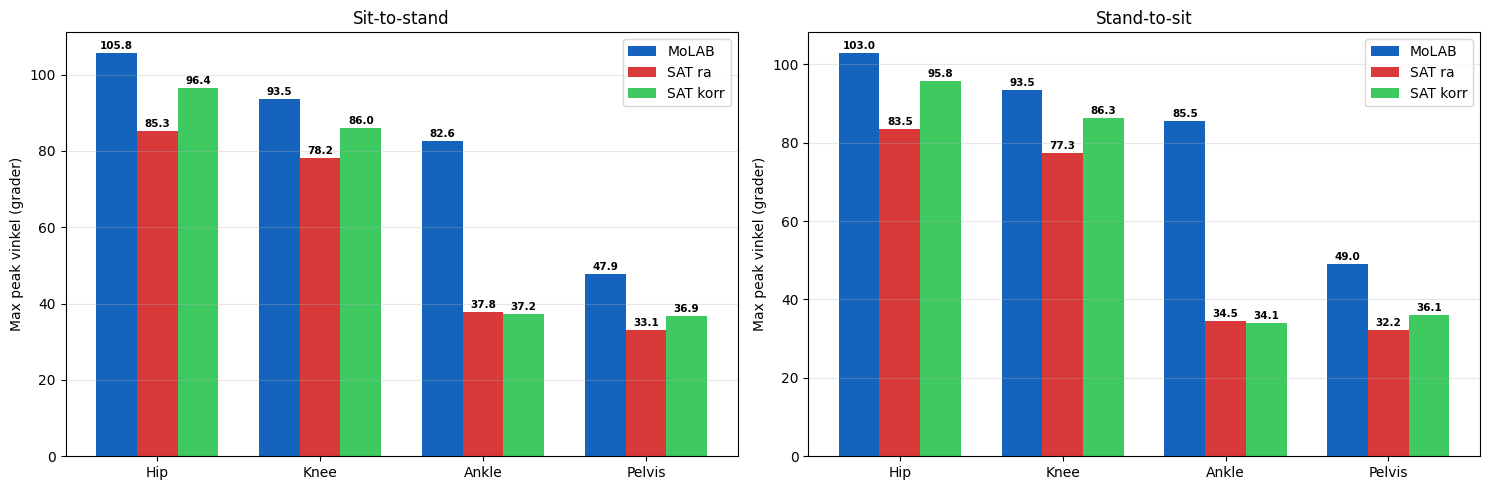

Saved peak_angles_comparison.png


In [29]:
import os
sources = ['molab', 'raw',    'corr']
labels  = ['MoLAB', 'SAT ra', 'SAT korr']
colors  = ['#0057B8', '#D62828', '#2DC653']

PEAK_ANGLES_DIR = '../data/processed/MAX_PEAK/peak_angles'
os.makedirs(PEAK_ANGLES_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
x = np.arange(len(JOINTS))
w = 0.25

for ax, direction, title in zip(axes,
        ['sit_to_stand', 'stand_to_sit'],
        ['Sit-to-stand', 'Stand-to-sit']):
    sub = peak_df[peak_df['direction'] == direction]
    for i, (src, lbl, col) in enumerate(zip(sources, labels, colors)):
        means = [sub[f'{src}_{jk}'].mean() for jk in JOINTS]
        bars  = ax.bar(x + (i - 1) * w, means, w, label=lbl, color=col, alpha=0.92)
        for bar, val in zip(bars, means):
            if not np.isnan(val) and val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([jl.replace(' (deg)', '') for jl in JLABELS])
    ax.set_ylabel('Max peak vinkel (grader)')
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PEAK_ANGLES_DIR}/peak_angles_comparison.png', dpi=150)
plt.show()
print('Saved peak_angles_comparison.png')

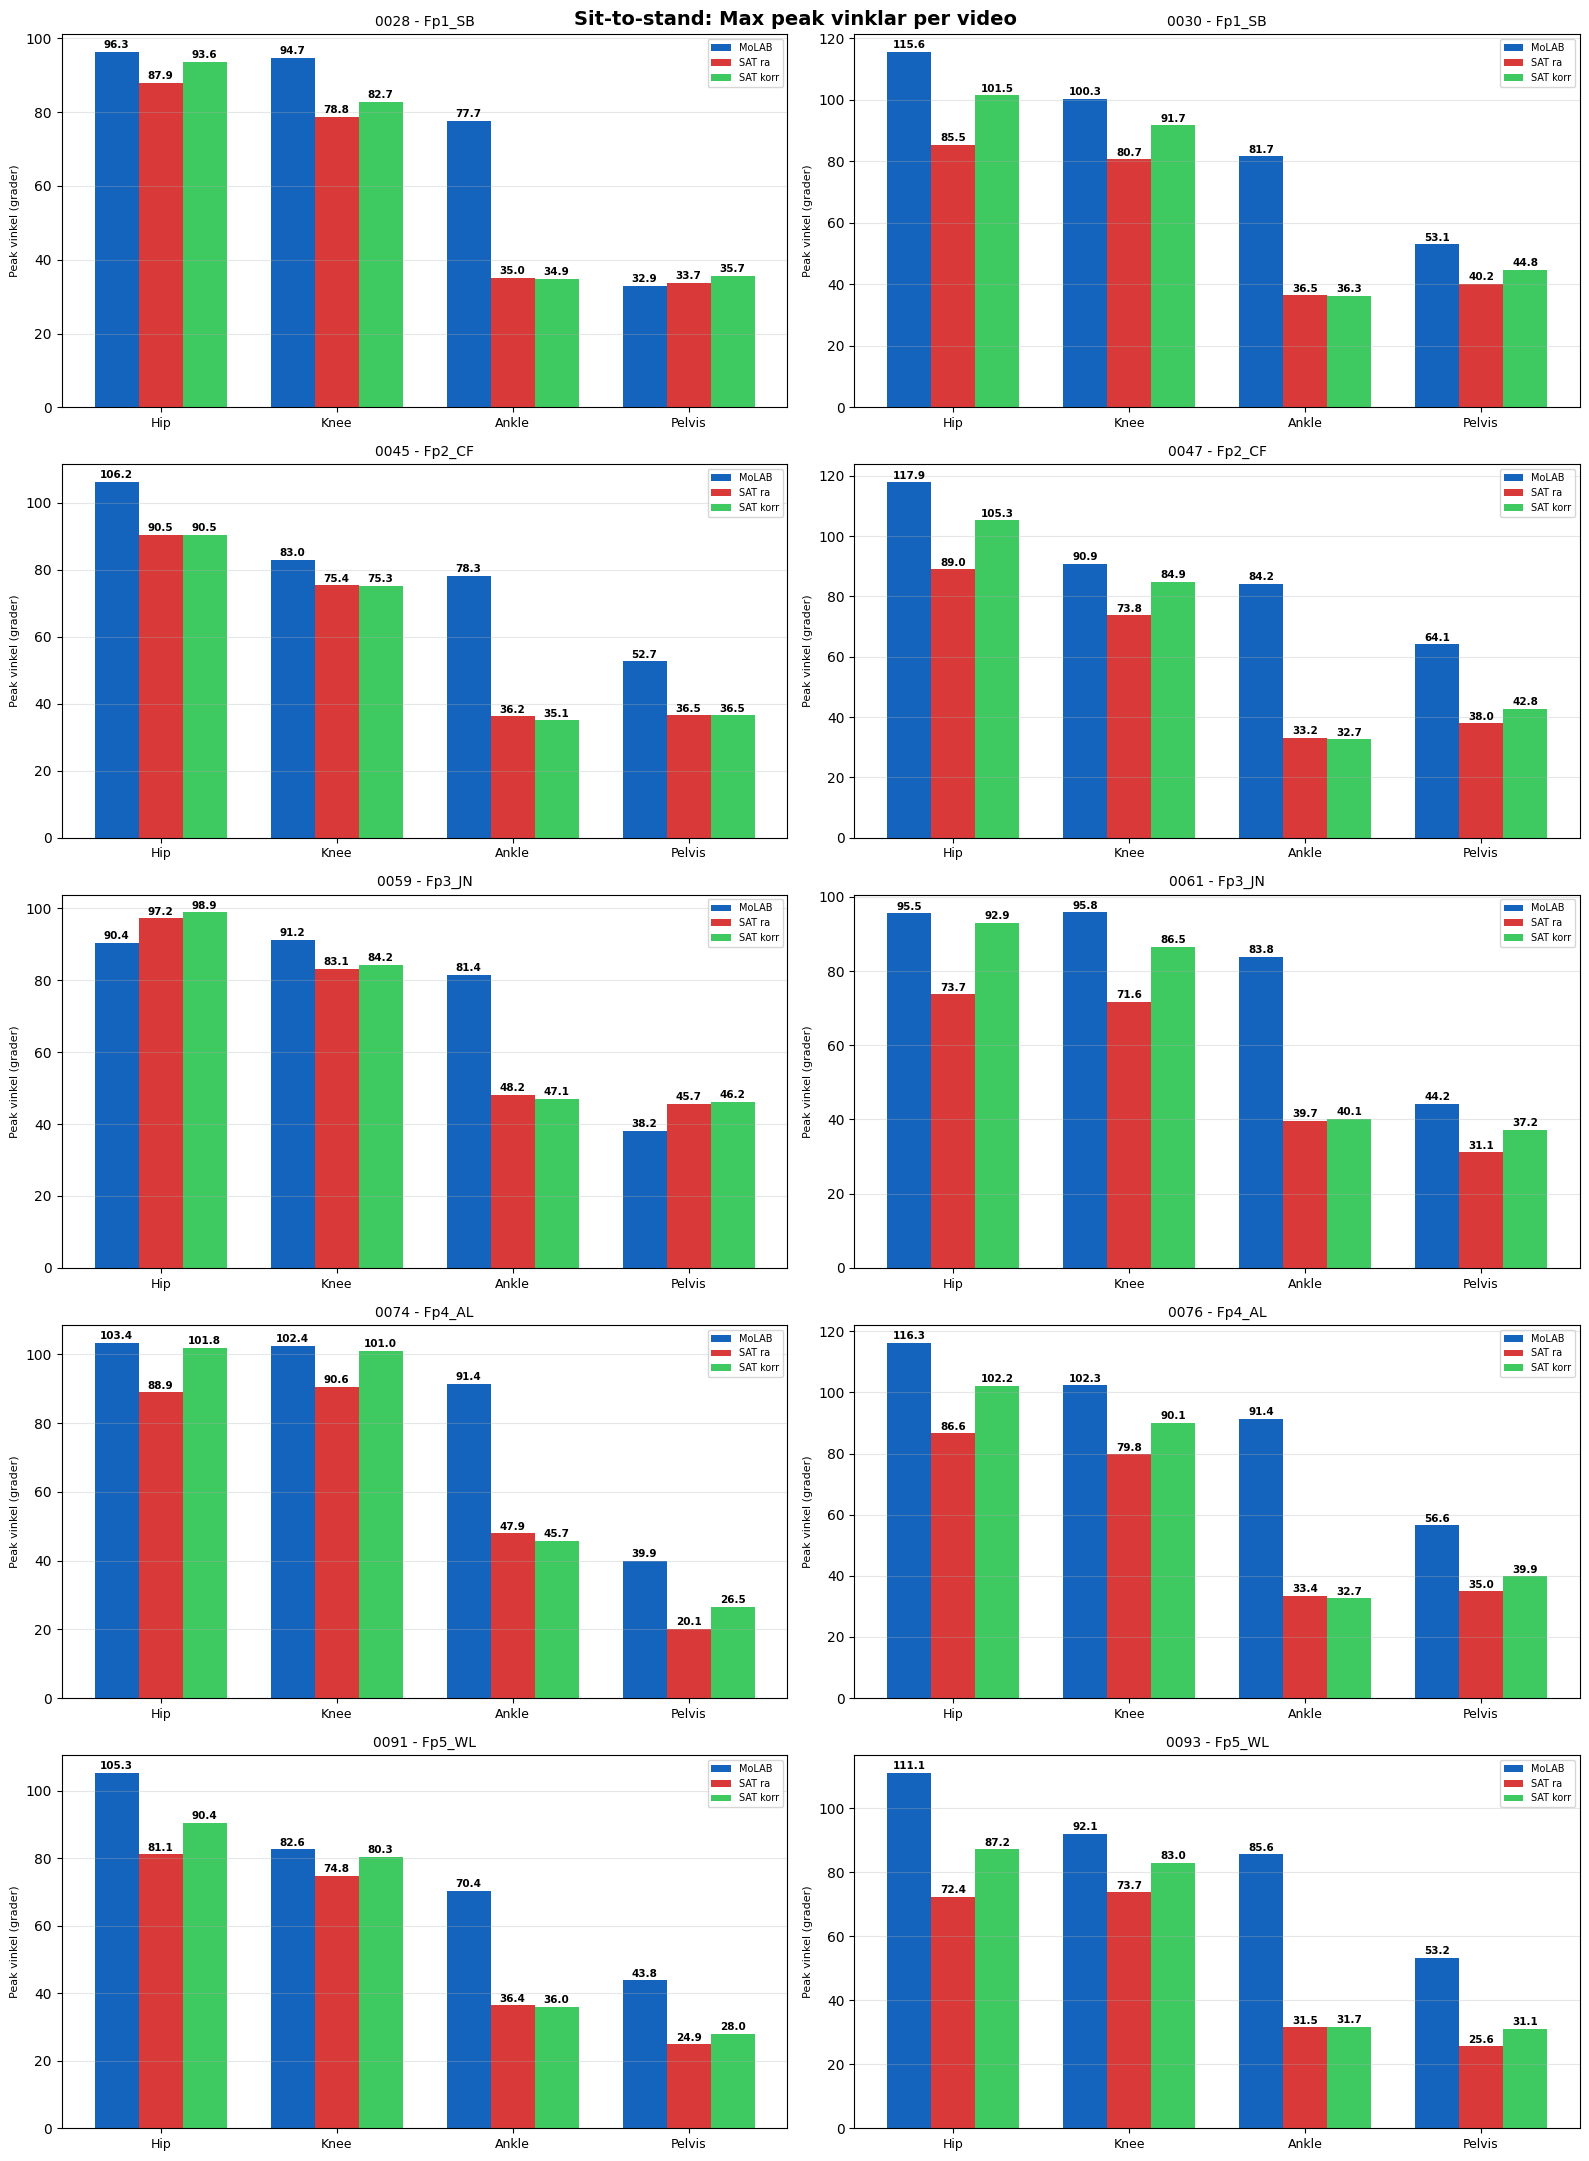

Saved peak_per_video_sit_to_stand.png


In [30]:
sub = peak_df[peak_df['direction'] == 'sit_to_stand'].sort_values('video')
x = np.arange(len(JOINTS))
w = 0.25

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
fig.suptitle('Sit-to-stand: Max peak vinklar per video', fontsize=14, fontweight='bold')

for ax, (_, row) in zip(axes.flat, sub.iterrows()):
    for i, (src, lbl, col) in enumerate(zip(sources, labels, colors)):
        vals = [row[f'{src}_{jk}'] for jk in JOINTS]
        bars = ax.bar(x + (i - 1) * w, vals, w, label=lbl, color=col, alpha=0.92)
        for bar, val in zip(bars, vals):
            if not np.isnan(val) and val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax.set_title(f"{row['video']} - {row['participant']}", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([jl.replace(' (deg)', '') for jl in JLABELS], fontsize=9)
    ax.set_ylabel('Peak vinkel (grader)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PEAK_ANGLES_DIR}/peak_per_video_sit_to_stand.png', dpi=150)
plt.show()
print('Saved peak_per_video_sit_to_stand.png')

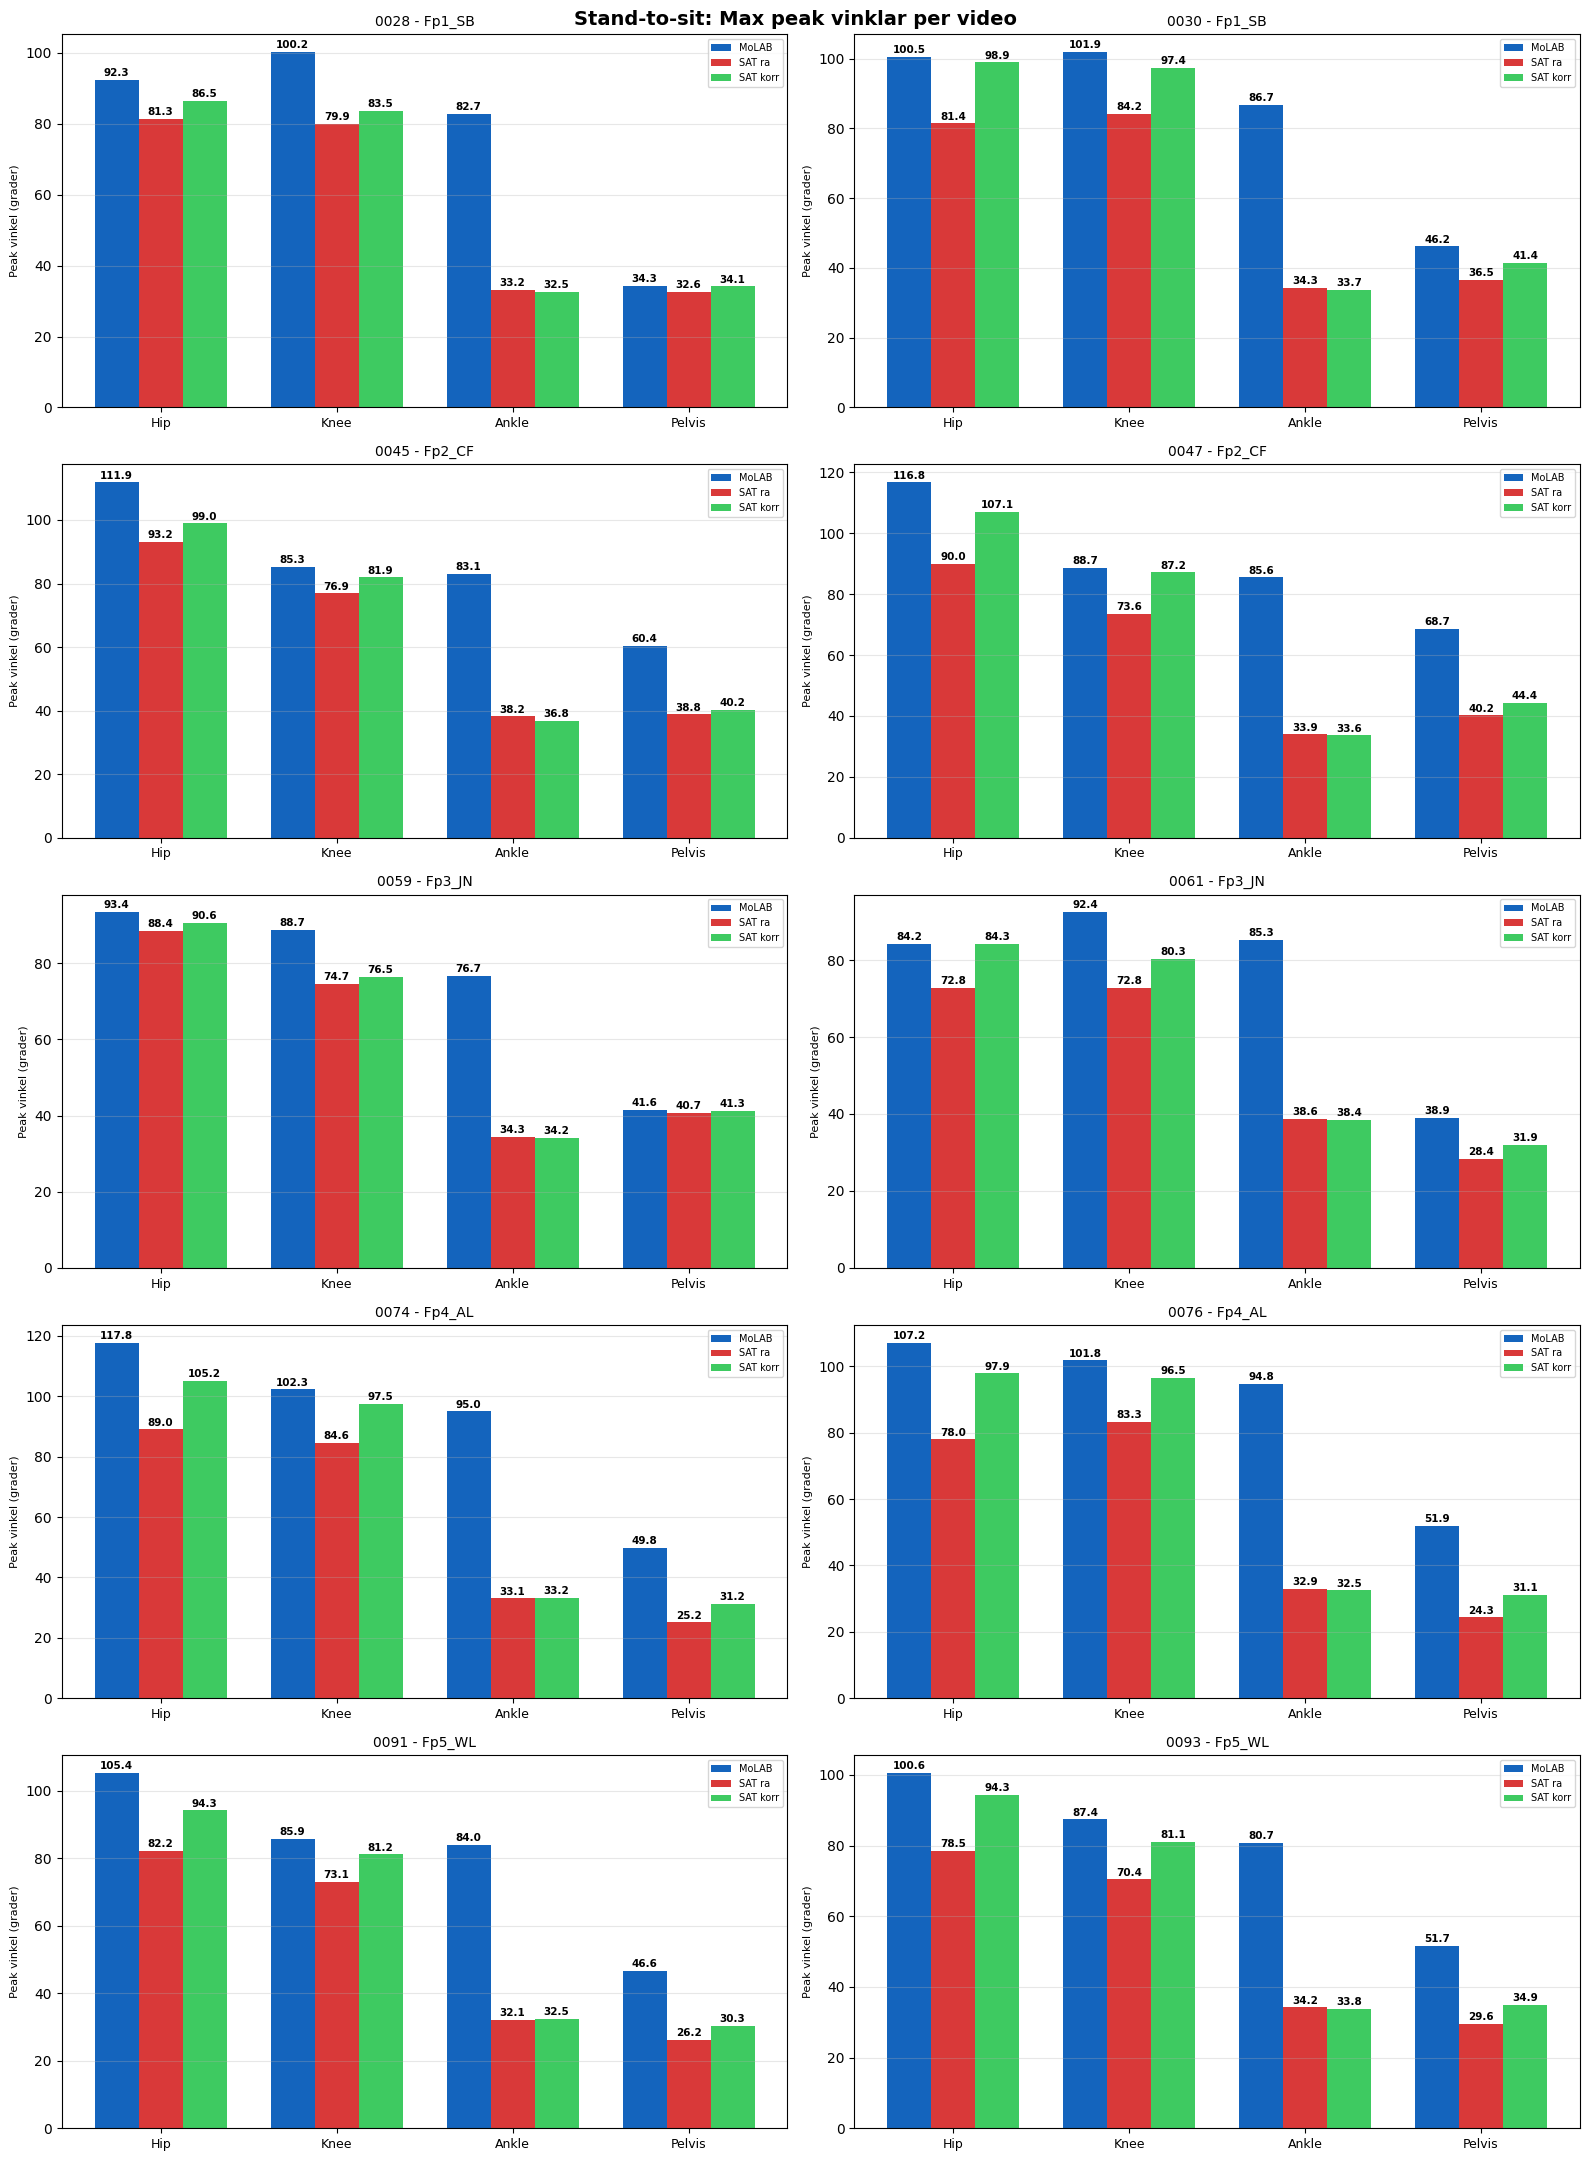

Saved peak_per_video_stand_to_sit.png


In [31]:
sub2 = peak_df[peak_df['direction'] == 'stand_to_sit'].sort_values('video')

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
fig.suptitle('Stand-to-sit: Max peak vinklar per video', fontsize=14, fontweight='bold')

for ax, (_, row) in zip(axes.flat, sub2.iterrows()):
    for i, (src, lbl, col) in enumerate(zip(sources, labels, colors)):
        vals = [row[f'{src}_{jk}'] for jk in JOINTS]
        bars = ax.bar(x + (i - 1) * w, vals, w, label=lbl, color=col, alpha=0.92)
        for bar, val in zip(bars, vals):
            if not np.isnan(val) and val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax.set_title(f"{row['video']} - {row['participant']}", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([jl.replace(' (deg)', '') for jl in JLABELS], fontsize=9)
    ax.set_ylabel('Peak vinkel (grader)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PEAK_ANGLES_DIR}/peak_per_video_stand_to_sit.png', dpi=150)
plt.show()
print('Saved peak_per_video_stand_to_sit.png')

## Left/Right Comparison

Computed separate left/right peaks for 40 video x direction x side combinations


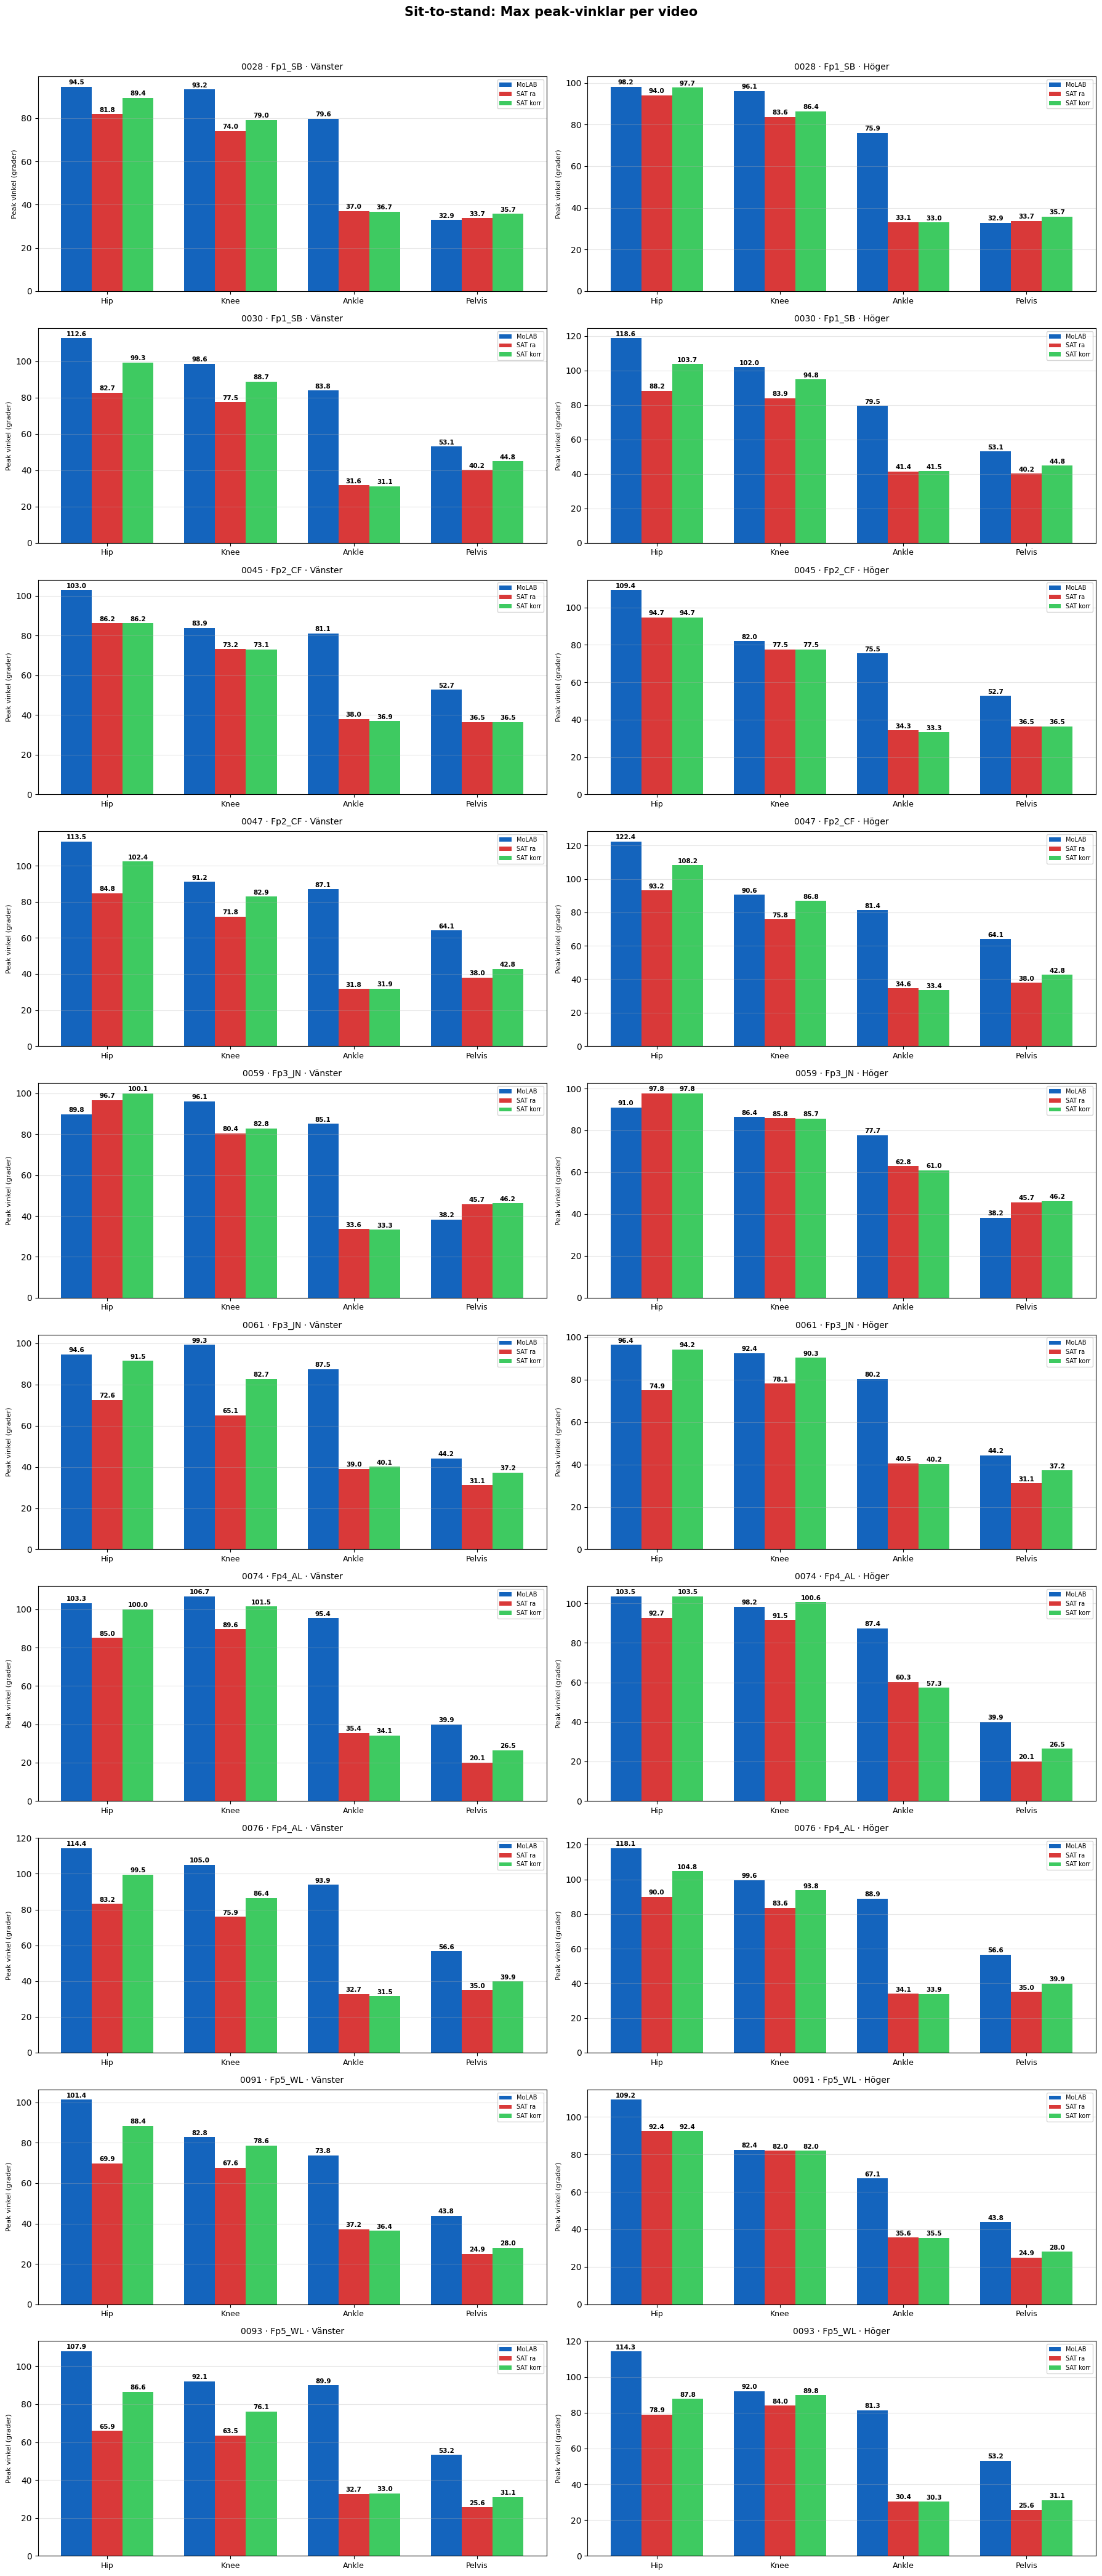

Saved peak_per_video_sit_to_stand_left_right.png


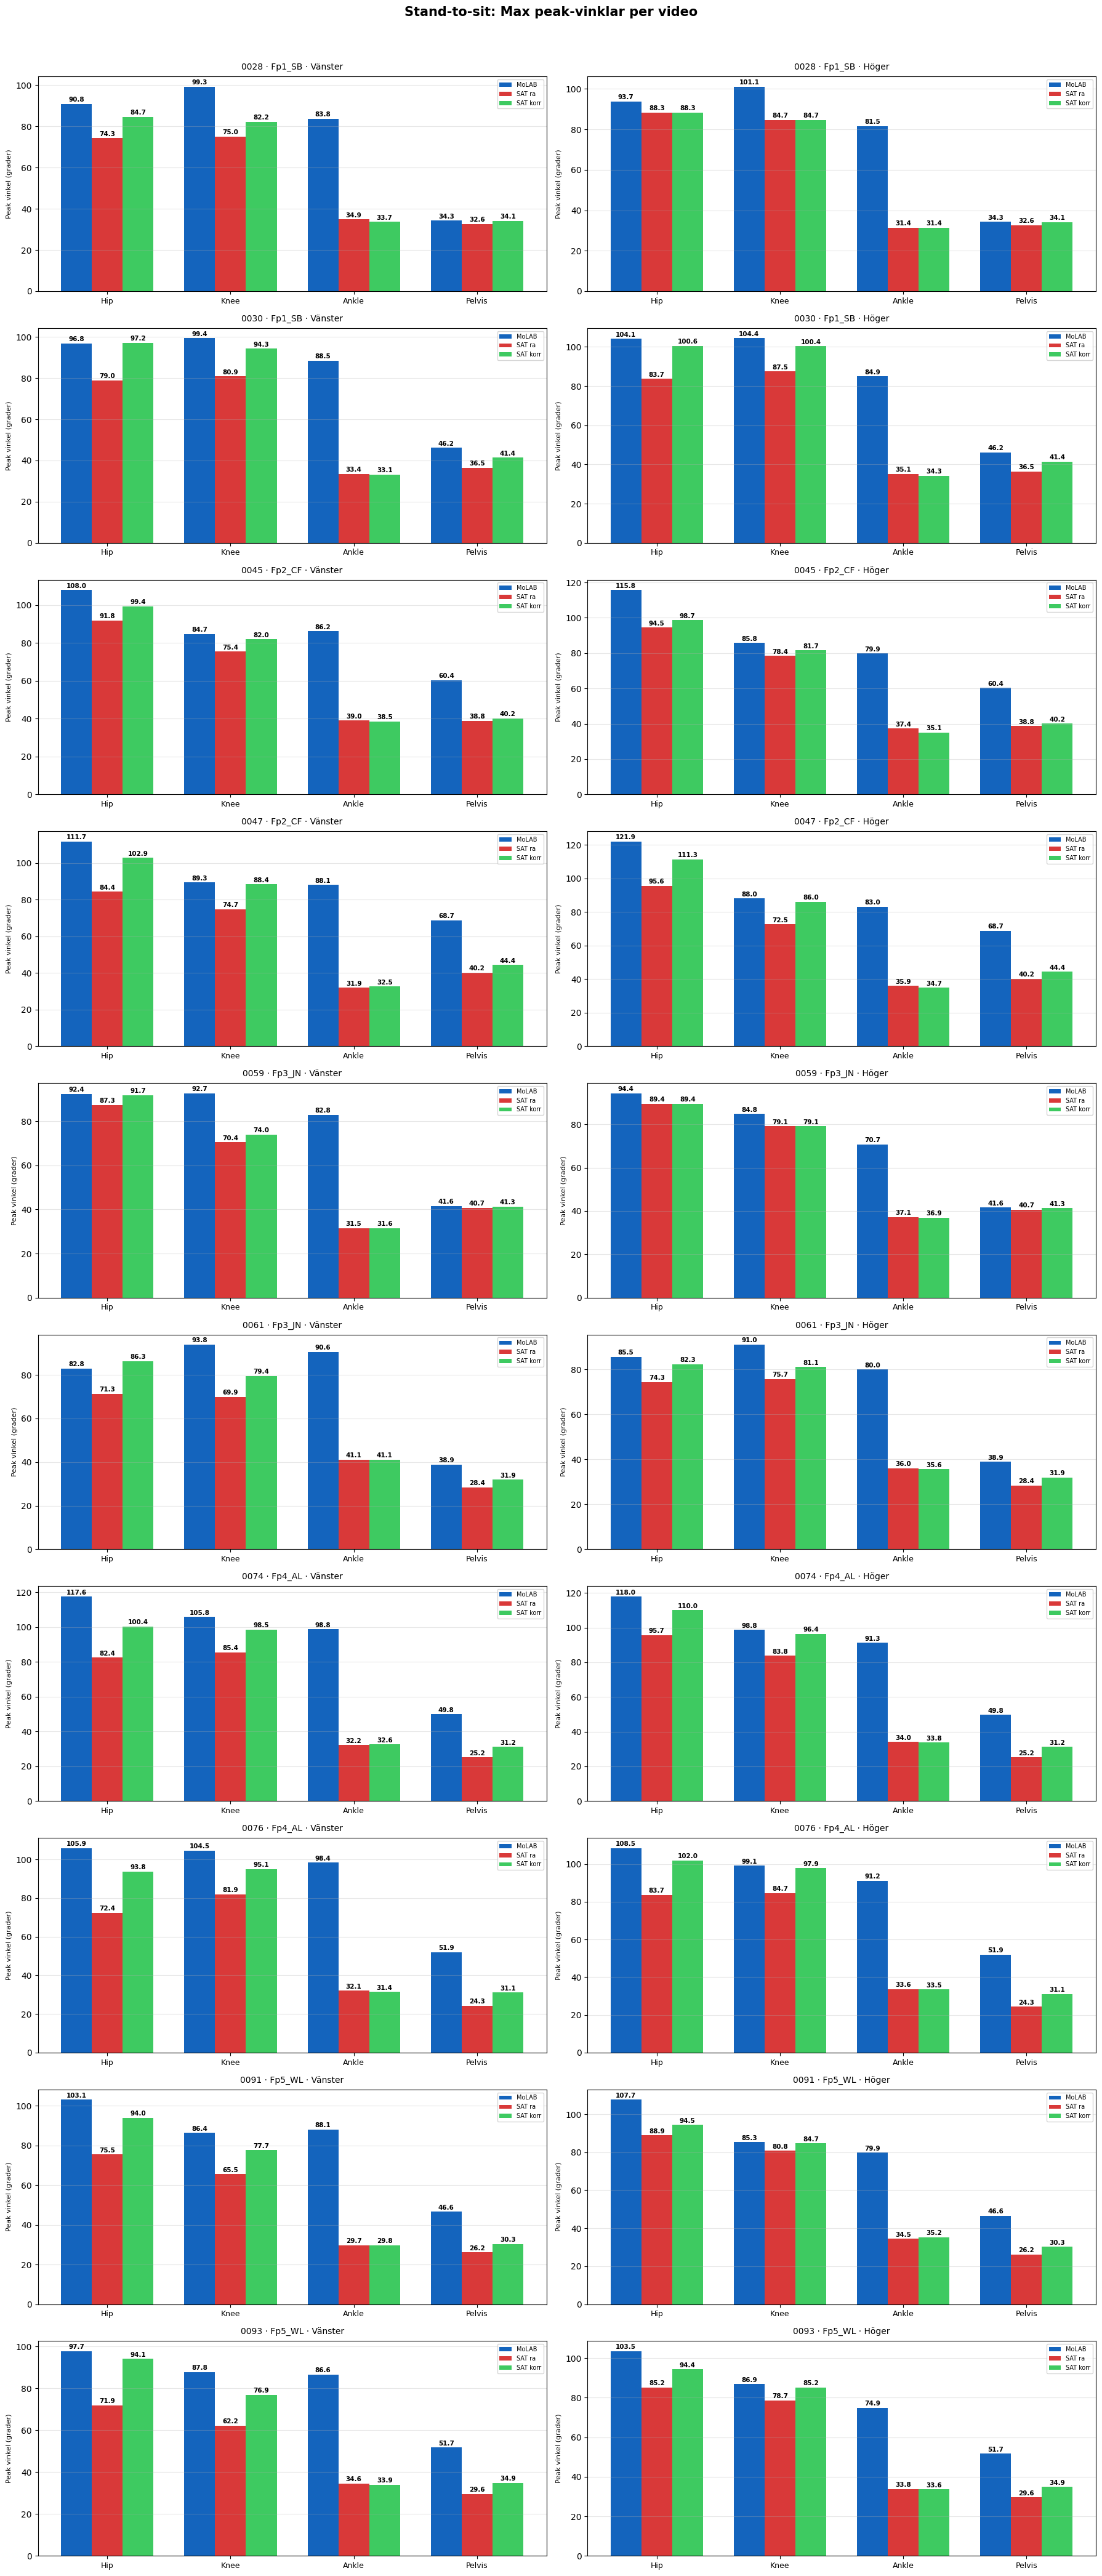

Saved peak_per_video_stand_to_sit_left_right.png


In [32]:
import os

try:
    PEAK_ANGLES_DIR
except NameError:
    PEAK_ANGLES_DIR = '../data/processed/MAX_PEAK/peak_angles'
    os.makedirs(PEAK_ANGLES_DIR, exist_ok=True)

try:
    sources, labels, colors
except NameError:
    sources = ['molab', 'raw', 'corr']
    labels  = ['MoLAB', 'SAT ra', 'SAT korr']
    colors  = ['#0057B8', '#D62828', '#2DC653']

LR_JOINTS  = ['hip', 'knee', 'heel', 'bal']
LR_JLABELS = ['Hip', 'Knee', 'Ankle', 'Pelvis']
ML_SIDE_COLS = {
    'L': {'hip': 'JointAngle/L_hip_X',  'knee': 'JointAngle/L_knee_X',  'heel': 'JointAngle/L_ankle_X'},
    'R': {'hip': 'JointAngle/R_hip_X',  'knee': 'JointAngle/R_knee_X',  'heel': 'JointAngle/R_ankle_X'},
}

peak_rows_lr = []
for direction, cfg in DIRS.items():
    for vid, fp in MAPPING:
        molab_f = glob.glob(f"{cfg['molab']}/{vid}_molab.csv")
        raw_f   = glob.glob(f"{cfg['raw']}/DJI_*_{vid}_D.csv")
        corr_f  = glob.glob(f"{cfg['corr']}/DJI_*_{vid}_D.csv")
        if not (molab_f and raw_f and corr_f):
            continue

        molab = pd.read_csv(molab_f[0])
        raw   = pd.read_csv(raw_f[0])
        corr  = pd.read_csv(corr_f[0])
        mask  = molab['molab_frame'].values >= 41

        raw_a  = compute_kp_angles(raw)
        corr_a = compute_kp_angles(corr)

        for side in ['L', 'R']:
            ml_side_peaks = {}
            for joint, col in ML_SIDE_COLS[side].items():
                vals = molab[col].values.copy()
                vals[mask] += ml_offsets[vid].get(col, 0)
                ml_side_peaks[joint] = np.max(np.abs(vals))

            peak_rows_lr.append({
                'direction':   direction,
                'video':       vid,
                'participant': fp,
                'side':        'left' if side == 'L' else 'right',
                'molab_hip':   round(ml_side_peaks['hip'], 1),
                'molab_knee':  round(ml_side_peaks['knee'], 1),
                'molab_heel':  round(ml_side_peaks['heel'], 1),
                'molab_bal':   round(np.max(np.abs(molab['JointAngle/pelvis_X'].values.copy() + np.where(mask, ml_offsets[vid].get('JointAngle/pelvis_X', 0), 0))), 1),
                'raw_hip':     round(np.max(np.abs(raw_a[f'{side}_hip'])), 1),
                'raw_knee':    round(np.max(np.abs(raw_a[f'{side}_knee'])), 1),
                'raw_heel':    round(np.max(np.abs(raw_a[f'{side}_heel'])), 1),
                'raw_bal':     round(np.max(np.abs(raw_a['bal'])), 1),
                'corr_hip':    round(np.max(np.abs(corr_a[f'{side}_hip'])), 1),
                'corr_knee':   round(np.max(np.abs(corr_a[f'{side}_knee'])), 1),
                'corr_heel':   round(np.max(np.abs(corr_a[f'{side}_heel'])), 1),
                'corr_bal':    round(np.max(np.abs(corr_a['bal'])), 1),
            })

peak_df_lr = pd.DataFrame(peak_rows_lr)
print(f'Computed separate left/right peaks for {len(peak_df_lr)} video x direction x side combinations')

def plot_peak_per_video_lr_side_by_side(direction):
    sub = peak_df_lr[peak_df_lr['direction'] == direction].sort_values(['video', 'side'])
    if sub.empty:
        print(f'No data for {direction}')
        return

    x = np.arange(len(LR_JOINTS))
    w = 0.25
    videos = sub[['video', 'participant']].drop_duplicates().sort_values('video')
    fig, axes = plt.subplots(len(videos), 2, figsize=(18, 4.2 * len(videos)), sharey=False)
    if len(videos) == 1:
        axes = np.array([axes])

    direction_title = 'Sit-to-stand' if direction == 'sit_to_stand' else 'Stand-to-sit'
    fig.suptitle(
        f'{direction_title}: Max peak-vinklar per video',
        fontsize=15,
        fontweight='bold',
        y=0.995,
    )

    for row_idx, (_, video_row) in enumerate(videos.iterrows()):
        vid = video_row['video']
        participant = video_row['participant']
        for col_idx, side in enumerate(['left', 'right']):
            ax = axes[row_idx, col_idx]
            row = sub[(sub['video'] == vid) & (sub['side'] == side)].iloc[0]
            for i, (src, lbl, col) in enumerate(zip(sources, labels, colors)):
                vals = [row[f'{src}_{jk}'] for jk in LR_JOINTS]
                bars = ax.bar(x + (i - 1) * w, vals, w, label=lbl, color=col, alpha=0.92)
                for bar, val in zip(bars, vals):
                    if not np.isnan(val) and val > 0:
                        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                                f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
            side_title = 'Vänster' if side == 'left' else 'Höger'
            ax.set_title(f'{vid} · {participant} · {side_title}', fontsize=10, pad=8)
            ax.set_xticks(x)
            ax.set_xticklabels(LR_JLABELS, fontsize=9)
            ax.set_ylabel('Peak vinkel (grader)', fontsize=8)
            ax.legend(fontsize=7)
            ax.grid(axis='y', alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.985])
    out_name = f"{PEAK_ANGLES_DIR}/peak_per_video_{direction}_left_right.png"
    plt.savefig(out_name, dpi=150)
    plt.show()
    print(f'Saved {Path(out_name).name}')

for _direction in ['sit_to_stand', 'stand_to_sit']:
    plot_peak_per_video_lr_side_by_side(_direction)

## Angle Plots with Peak Markers

In [33]:
import os

KC_MOLAB_FULL_DIR = '../data/processed/molab'
KC_ANGLE_PLOTS_DIR = '../data/processed/MAX_PEAK'

KC_MAPPING = [
    ('0028', 'Fp1_SB'), ('0030', 'Fp1_SB'),
    ('0045', 'Fp2_CF'), ('0047', 'Fp2_CF'),
    ('0059', 'Fp3_JN'), ('0061', 'Fp3_JN'),
    ('0074', 'Fp4_AL'), ('0076', 'Fp4_AL'),
    ('0091', 'Fp5_WL'), ('0093', 'Fp5_WL'),
]

KC_BEEP_TIMES = {
    '0028': 9.14, '0030': 5.38, '0045': 5.88, '0047': 6.12,
    '0059': 5.70, '0061': 6.10, '0074': 5.42, '0076': 5.54,
    '0091': 5.52, '0093': 5.00,
}
KC_CORRECTIONS = {'0028': 0.52}

KC_PLOT_JOINTS = [
    ('L_knee_X',  'Left Knee'),
    ('R_knee_X',  'Right Knee'),
    ('L_hip_X',   'Left Hip'),
    ('R_hip_X',   'Right Hip'),
    ('L_ankle_X', 'Left Ankle'),
    ('R_ankle_X', 'Right Ankle'),
    ('pelvis_X',  'Pelvis'),
]

KC_UP_TIME_DICT = {
    '028': (9.90, 10.44, 10.60, 11.20, 11.20, 11.77),
    '030': (5.80, 6.12,  6.28,  6.80,  6.80,  7.63),
    '045': (6.54, 6.74,  6.90,  7.36,  7.36,  7.98),
    '047': (7.03, 7.36,  7.52,  7.88,  7.88,  8.80),
    '059': (6.65, 6.90,  7.06,  8.10,  8.10,  9.11),
    '061': (7.00, 7.40,  7.56,  8.20,  8.20,  9.00),
    '074': (6.07, 6.22,  6.38,  6.80,  6.80,  7.27),
    '076': (5.20, 5.80,  5.96,  6.34,  6.34,  7.20),
    '091': (6.39, 6.52,  6.68,  7.14,  7.14,  7.61),
    '093': (5.86, 6.22,  6.38,  6.74,  6.74,  7.50),
}

KC_DOWN_TIME_DICT = {
    '028': (11.87, 11.90, 12.06, 12.57, 12.82),
    '030': (8.07,  9.70,  9.94,  10.64, 11.16),
    '045': (7.94,  7.96,  8.04,  8.74,  9.26),
    '047': (9.20,  10.14, 10.36, 11.10, 11.70),
    '059': (9.11,  9.18,  9.50,  10.37, 11.06),
    '061': (10.57, 10.88, 11.26, 12.26, 13.00),
    '074': (7.27,  7.30,  7.42,  7.88,  8.14),
    '076': (8.27,  8.72,  9.08,  9.73,  10.32),
    '091': (7.56,  7.58,  7.70,  8.09,  8.18),
    '093': (8.50,  9.24,  9.56,  10.08, 10.74),
}

def segment_angle_2d_kc(ax, ay, bx, by, cx, cy, dx, dy):
    v1x, v1y = bx - ax, by - ay
    v2x, v2y = dx - cx, dy - cy
    dot  = v1x * v2x + v1y * v2y
    norm = np.sqrt(v1x**2 + v1y**2) * np.sqrt(v2x**2 + v2y**2) + 1e-8
    return 180 - np.degrees(np.arccos(np.clip(dot / norm, -1, 1)))

def compute_kp_angles_kc(kp):
    kp = kp.copy()
    x_cols = [c for c in kp.columns if c.endswith('_x')]
    kp[x_cols] *= VIDEO_ASPECT
    angles = {}
    for side, s in [('L', 'left'), ('R', 'right')]:
        angles[f'{side}_knee_X'] = joint_angle_2d(
            kp[f'{s}_hip_x'].values,    kp[f'{s}_hip_y'].values,
            kp[f'{s}_knee_x'].values,   kp[f'{s}_knee_y'].values,
            kp[f'{s}_ankle_x'].values,  kp[f'{s}_ankle_y'].values,
        )
        angles[f'{side}_hip_X'] = joint_angle_2d(
            kp[f'{s}_shoulder_x'].values, kp[f'{s}_shoulder_y'].values,
            kp[f'{s}_hip_x'].values,      kp[f'{s}_hip_y'].values,
            kp[f'{s}_knee_x'].values,     kp[f'{s}_knee_y'].values,
        )
        angles[f'{side}_ankle_X'] = segment_angle_2d_kc(
            kp[f'{s}_heel_x'].values,       kp[f'{s}_heel_y'].values,
            kp[f'{s}_foot_index_x'].values, kp[f'{s}_foot_index_y'].values,
            kp[f'{s}_ankle_x'].values,      kp[f'{s}_ankle_y'].values,
            kp[f'{s}_knee_x'].values,       kp[f'{s}_knee_y'].values,
        )
    angles['pelvis_X'] = trunk_angle_2d(kp)
    return angles

kc_offsets = {}
for _vid, _fp in KC_MAPPING:
    _full = pd.read_csv(f'{KC_MOLAB_FULL_DIR}/{_vid}_molab.csv')
    _pre  = _full[_full['molab_frame'] < 41]
    kc_offsets[_vid] = {j: _pre[f'JointAngle/{j}'].mean() for j, _ in KC_PLOT_JOINTS}

_FIG_LEGEND_HANDLES = [
    plt.Line2D([0], [0], color='steelblue', linewidth=1.8, label='MoLab'),
    plt.Line2D([0], [0], color='tomato',    linewidth=1.8, label='SAT'),
    plt.Line2D([0], [0], color='green',     linewidth=1.8, label='SAT corrected'),
]

def mark_all_peaks(ax, sources):
    BASE, STEP = 14, 36

    peaks = []
    for time_arr, angle_arr, color, go_left in sources:
        arr = np.asarray(angle_arr)
        idx = int(np.argmax(np.abs(arr)))
        peaks.append(dict(t=float(time_arr[idx]), v=float(arr[idx]),
                          color=color, go_left=go_left))

    lines_yd = [ln.get_ydata() for ln in ax.lines if len(ln.get_ydata()) > 1]
    d_min = min(np.nanmin(d) for d in lines_yd) if lines_yd else 0
    d_max = max(np.nanmax(d) for d in lines_yd) if lines_yd else 1
    d_range = max(d_max - d_min, 1e-9)

    right = [p for p in peaks if not p['go_left']]
    left  = [p for p in peaks if p['go_left']]

    right_desc = sorted(right, key=lambda p: -p['v'])
    top_frac = (right_desc[0]['v'] - d_min) / d_range if right_desc else 0
    flip_right = top_frac > 0.75

    for j, p in enumerate(right_desc):
        if flip_right:
            p.update(x_off=12, ha='left', y_off=-(BASE + j * STEP), va='top')
        else:
            p.update(x_off=12, ha='left', y_off=BASE + j * STEP,    va='bottom')

    for p in left:
        y_frac = (p['v'] - d_min) / d_range
        if y_frac > 0.75:
            p.update(x_off=-12, ha='right', y_off=-36, va='top')
        else:
            p.update(x_off=-12, ha='right', y_off=42,  va='bottom')

    for p in peaks:
        ax.annotate(
            f"{abs(p['v']):.1f}°  {p['t']:.2f} s",
            xy=(p['t'], p['v']),
            textcoords='offset points',
            xytext=(p['x_off'], p['y_off']),
            ha=p['ha'], va=p['va'],
            fontsize=6.5, color=p['color'], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=p['color'], linewidth=1.1, alpha=0.95),
            arrowprops=dict(arrowstyle='->', color=p['color'], lw=0.9,
                            shrinkA=0, shrinkB=3),
            zorder=8,
        )
    for p in peaks:
        ax.plot(p['t'], p['v'], 'o', color=p['color'], markersize=6, zorder=10,
                markeredgecolor='white', markeredgewidth=1.0)

def plot_molab_angles_with_peaks(molab_dir, kp_dir, kp_cor_dir, kp_pattern,
                                  title, out_dir, label, phase_dict, phase_indices):
    os.makedirs(out_dir, exist_ok=True)
    for vid, fp in KC_MAPPING:
        molab  = pd.read_csv(f'{molab_dir}/{vid}_molab.csv')
        offset = KC_BEEP_TIMES[vid] - 4 + KC_CORRECTIONS.get(vid, 0)
        t    = molab['molab_time'].values + offset
        mask = molab['molab_frame'].values >= 41

        kp_files  = glob.glob(f'{kp_dir}/{kp_pattern.format(vid=vid)}')
        kp_angles, kp_time = None, None
        if kp_files:
            kp        = pd.read_csv(kp_files[0])
            kp_time   = kp['frame'].values / VIDEO_FPS
            kp_angles = compute_kp_angles_kc(kp)

        kp_cor_files  = glob.glob(f'{kp_cor_dir}/{kp_pattern.format(vid=vid)}')
        kp_cor_angles, kp_cor_time = None, None
        if kp_cor_files:
            kp_cor        = pd.read_csv(kp_cor_files[0])
            kp_cor_time   = kp_cor['frame'].values / VIDEO_FPS
            kp_cor_angles = compute_kp_angles_kc(kp_cor)

        vid3   = vid[1:]
        phases = [(phase_dict[vid3][idx], lbl) for idx, lbl in phase_indices if vid3 in phase_dict]

        fig, axes = plt.subplots(4, 2, figsize=(14, 16))
        fig.suptitle(f'{title} {vid}: {fp}', fontsize=13, fontweight='bold', y=0.995)
        for row in range(3):
            axes[row, 1].sharey(axes[row, 0])

        for i, (joint, jlabel) in enumerate(KC_PLOT_JOINTS):
            ax  = axes.flat[i]
            raw = molab[f'JointAngle/{joint}'].values.copy()
            raw[mask] += kc_offsets[vid][joint]

            ax.plot(t, raw, linewidth=1.2, color='steelblue', zorder=3)
            if kp_angles is not None and joint in kp_angles:
                ax.plot(kp_time, kp_angles[joint], linewidth=1.2,
                        color='tomato', alpha=0.85, zorder=3)
            if kp_cor_angles is not None and joint in kp_cor_angles:
                ax.plot(kp_cor_time, np.asarray(kp_cor_angles[joint]), linewidth=1.2,
                        color='green', alpha=0.85, zorder=3)

            peak_sources = [(t, raw, 'steelblue', False)]
            if kp_angles is not None and joint in kp_angles:
                peak_sources.append((kp_time, kp_angles[joint], 'tomato', True))
            if kp_cor_angles is not None and joint in kp_cor_angles:
                peak_sources.append((kp_cor_time, kp_cor_angles[joint], 'green', False))
            mark_all_peaks(ax, peak_sources)

            for phase_t, phase_lbl in phases:
                ax.axvline(phase_t, color='dimgray', linestyle='--', linewidth=0.7, zorder=2)
                ax.text(phase_t + 0.01, 0.02, phase_lbl,
                        transform=ax.get_xaxis_transform(),
                        ha='left', va='bottom', fontsize=6.5,
                        color='dimgray', clip_on=True)

            ax.set_title(jlabel, fontsize=10, pad=6)
            ax.set_xlabel('Video time (s)', fontsize=8)
            ax.set_ylabel('Angle (deg)', fontsize=8)
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.25, zorder=1)
            ax.spines[['top', 'right']].set_visible(False)

        fig.legend(handles=_FIG_LEGEND_HANDLES, loc='upper center', ncol=3,
                   bbox_to_anchor=(0.5, 0.988), fontsize=9,
                   framealpha=0.9, edgecolor='lightgray')

        axes.flat[-1].set_visible(False)
        plt.tight_layout(rect=[0, 0, 1, 0.972])
        plt.savefig(f'{out_dir}/{vid}_{fp}_{label}.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f'  Saved {vid}_{fp}_{label}.png')

plot_molab_angles_with_peaks(
    '../data/processed/molab_cropped',
    '../data/processed/keypoints_combined',
    '../data/processed/keypoints_corrected',
    'DJI_*_{vid}_D.csv',
    'MoLab vs SAT Sit-to-stand',
    f'{KC_ANGLE_PLOTS_DIR}/sit_to_stand',
    'sit_to_stand',
    phase_dict=KC_UP_TIME_DICT,
    phase_indices=[(1, 'rörelsestart'), (4, 'uppresningsfas')],
)
plot_molab_angles_with_peaks(
    '../data/processed/molab_cropped_down',
    '../data/processed/keypoints_combined_down',
    '../data/processed/keypoints_corrected_down',
    'DJI_*_{vid}_D.csv',
    'MoLab vs SAT Stand-to-sit',
    f'{KC_ANGLE_PLOTS_DIR}/stand_to_sit',
    'stand_to_sit',
    phase_dict=KC_DOWN_TIME_DICT,
    phase_indices=[(1, 'rörelsestart'), (3, 'bakåtgående')],
)
print('Done, MAX_PEAK updated')

  Saved 0028_Fp1_SB_sit_to_stand.png
  Saved 0030_Fp1_SB_sit_to_stand.png
  Saved 0045_Fp2_CF_sit_to_stand.png
  Saved 0047_Fp2_CF_sit_to_stand.png
  Saved 0059_Fp3_JN_sit_to_stand.png
  Saved 0061_Fp3_JN_sit_to_stand.png
  Saved 0074_Fp4_AL_sit_to_stand.png
  Saved 0076_Fp4_AL_sit_to_stand.png
  Saved 0091_Fp5_WL_sit_to_stand.png
  Saved 0093_Fp5_WL_sit_to_stand.png
  Saved 0028_Fp1_SB_stand_to_sit.png
  Saved 0030_Fp1_SB_stand_to_sit.png
  Saved 0045_Fp2_CF_stand_to_sit.png
  Saved 0047_Fp2_CF_stand_to_sit.png
  Saved 0059_Fp3_JN_stand_to_sit.png
  Saved 0061_Fp3_JN_stand_to_sit.png
  Saved 0074_Fp4_AL_stand_to_sit.png
  Saved 0076_Fp4_AL_stand_to_sit.png
  Saved 0091_Fp5_WL_stand_to_sit.png
  Saved 0093_Fp5_WL_stand_to_sit.png
Done, MAX_PEAK updated
